In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from src.utils import run_pipeline

In [3]:
def _to_uint8(img: np.ndarray) -> np.ndarray:
    img = np.clip(img, 0, 1)
    return (img * 255).astype(np.uint8)

In [4]:
image_path = '../src/data/leaf.png'
img_bgr = cv2.imread(image_path, cv2.IMREAD_COLOR)
V, mask0, mask1, mask_ref, labels,labels_vis, overlay = run_pipeline(img_bgr, thr_method="otsu", save_prefix=None)

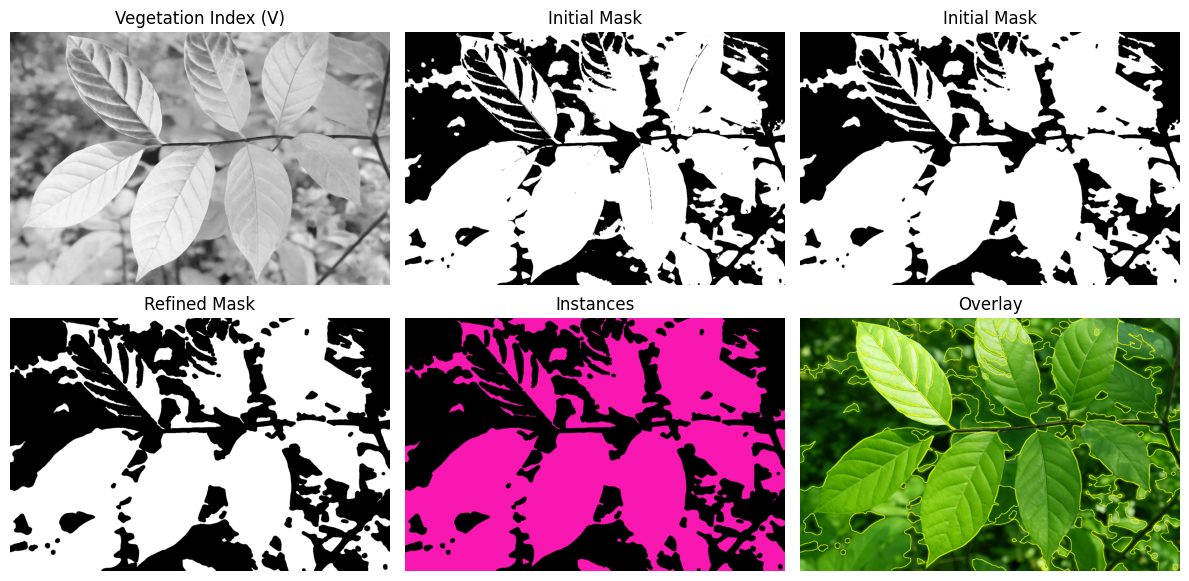

In [6]:
plt.figure(figsize=(12, 6))

plt.subplot(2, 3, 1)
plt.title("Vegetation Index (V)")
plt.imshow(_to_uint8(V), cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.title("Initial Mask")
plt.imshow(mask0, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.title("Initial Mask")
plt.imshow(mask1, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.title("Refined Mask")
plt.imshow(mask_ref, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.title("Instances")
plt.imshow(cv2.cvtColor(labels_vis, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(2, 3, 6)
plt.title("Overlay")
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.tight_layout()
plt.show()